
# Advanced Statistical Inference -- Gaussian Process Regression

In this lab, you will build a Gaussian process regression model from first principles.

By the end of the lab, you should be able to:
- construct and visualize a Gaussian process prior;
- compute the Gaussian process posterior for regression;
- understand how the kernel hyperparameters affect smoothness and uncertainty;
- evaluate hyperparameters with the marginal likelihood;
- optimize hyperparameters with automatic differentiation.

This lab is deliberately structured like the MCMC classification lab: most of the scaffolding is provided,
and your job is to complete the missing pieces and interpret the outputs.

**How to approach this lab:**
- work through the cells in order;
- implement each missing block before moving on;
- after each plot, pause and answer the short conceptual questions;
- compare what you see with the theory from the lecture notes.


**Important**:

This lab uses JAX throughout. The goal here is not to re-teach JAX syntax.
If you need a refresher on `jax.numpy`, `jax.grad`, or `jax.value_and_grad`, revisit the general tutorial:

`tutorials/02_Tutorial_JAX.ipynb`

You should have completed that tutorial before continuing.

## Setup
First, import the libraries and configure the plotting style.

In [2]:
import functools
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

warnings.filterwarnings("ignore")

colab = "google.colab" in str(get_ipython())
rc("figure", **{"dpi": 200})
rc(
    "axes",
    **{"spines.right": False, "spines.top": False, "xmargin": 0.0, "ymargin": 0.05},
)


def plot_data(X, y, ax):
    """Plot 1D regression observations."""
    config = dict(edgecolor="black", linewidth=1, facecolor="tab:blue")
    ax.scatter(X, y, label="Observed data", zorder=10, **config)


def plot_gp(x, mean, cov, palette="Greens", **kwargs):
    """Plot GP mean and uncertainty bands."""
    ax = kwargs.pop("ax", plt.gca())
    cmap = plt.get_cmap(palette)
    ci = [1, 2, 3]
    colors = (ci - np.min(ci)) / (np.max(ci) - np.min(ci) + 3) + 0.1
    x = x.flatten()
    ax.plot(x, mean, color=cmap(0.9), lw=4)
    for i, c in enumerate(ci[::-1]):
        up = mean + c * np.sqrt(np.diag(cov))
        lo = mean - c * np.sqrt(np.diag(cov))
        color = cmap(colors[i])
        ax.fill_between(x, up, lo, color=color, alpha=0.95, **kwargs)
    return ax


def plot_samples(x, samples, palette="Greens", **kwargs):
    """Plot a subset of sampled functions."""
    ax = kwargs.pop("ax", plt.gca())
    N = kwargs.pop("N", 20)
    cmap = plt.get_cmap(palette)
    idx = np.random.randint(0, samples.shape[0], N)
    ax.plot(x, samples[idx].T, color=cmap(0.5), lw=1, alpha=0.75, **kwargs)
    return ax

## Data

We will work with a one-dimensional regression dataset generated from a smooth latent function with noise.
The input region contains a gap on purpose: later, this will make the posterior uncertainty easier to interpret.

**Exercise:**
Run the next cell to generate and visualize the data.

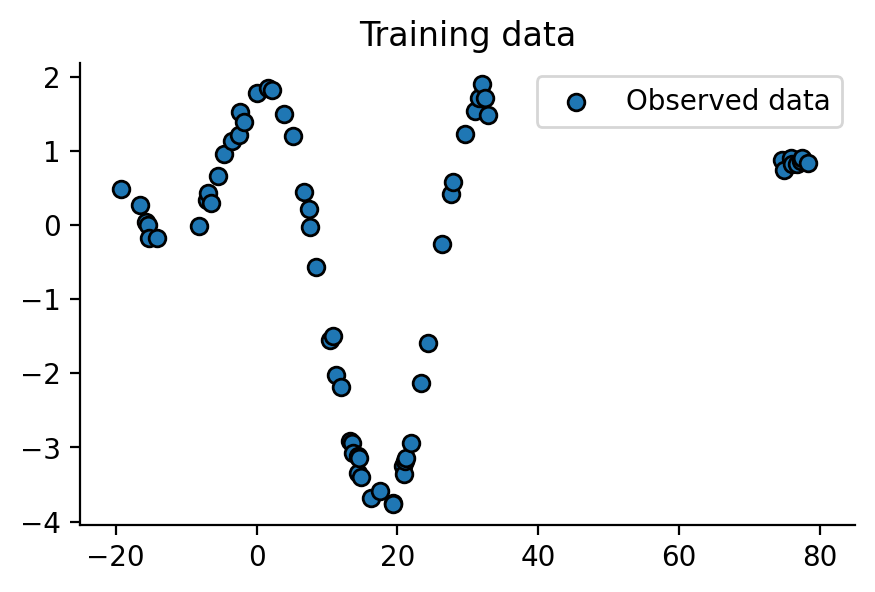

In [3]:
np.random.seed(3424121)


def make_dataset(a=-20, b=80, N=64, M=200, gap_ratio=0.4, ampl=1.6, leng=8, sn2=0.01):
    """Generate a toy 1D regression problem with a gap in the input space."""

    def make_random_gap(X, gap_ratio=0.2):
        a, b = X.min(), X.max()
        gap_a = a + np.random.rand() * (b - a) * (1 - gap_ratio)
        gap_b = gap_a + (b - a) * gap_ratio
        idx = np.logical_and(gap_a < X, X < gap_b)
        X[idx] = a + np.random.rand(idx.sum()) * (gap_a - a)
        return X

    def sample_random_function(X, ampl=1, leng=1, sn2=0.1):
        n, x = X.shape[0], X / leng
        sum_xx = np.sum(x * x, 1).reshape(-1, 1).repeat(n, 1)
        D = sum_xx + sum_xx.transpose() - 2 * np.matmul(x, x.transpose())
        C = ampl**2 * np.exp(-0.5 * D) + np.eye(n) * sn2
        return np.random.multivariate_normal(np.zeros(n), C)

    X = np.random.rand(N, 1) * (b - a) + a
    X = make_random_gap(X, gap_ratio=gap_ratio)
    ind = np.argsort(X[..., 0])
    y = sample_random_function(X, ampl=ampl, leng=leng, sn2=sn2)
    Xt = np.linspace(a - 5, b + 5, M).reshape(-1, 1)
    return X[ind], y[ind], Xt


X, y, Xt = make_dataset()

fig, ax = plt.subplots(figsize=[5, 3])
plot_data(X, y, ax)
ax.set_xlim(Xt.min(), Xt.max())
ax.set_title("Training data")
ax.legend()
plt.show()

**Where is the input gap?**

The input gap is located approximately between x ≈ 30 and x ≈ 75,
where no training observations are present.

**In which region would you expect the posterior uncertainty to be largest?**

We expect the posterior uncertainty to be largest in the gap region (30 ≲ x ≲ 75),
since without observations the GP has no information to constrain the function
and reverts toward the prior.

**Do you expect a very small or a very large lengthscale to fit this dataset better?**

An intermediate-to-large lengthscale is expected to fit this dataset better.
As λ → 0, points become uncorrelated and the function oscillates wildly.
As λ → +∞, the function becomes extremely smooth and nearly constant,
which would fail to capture the local structure visible in the data.
Given the gap in the input space, a sufficiently large lengthscale is needed
to maintain smooth predictions across the unobserved region, without
being so large that all local variation is lost.

# 1. Gaussian Process Prior

A Gaussian process defines a distribution over functions.
For any finite set of inputs, the corresponding function values follow a multivariate Gaussian:

$$
p(\boldsymbol f) = \mathcal{N}(\boldsymbol\mu, \boldsymbol\Sigma).
$$

In this lab, we use a zero-mean prior and an RBF kernel:

$$
\kappa(\boldsymbol x, \boldsymbol x') = \sigma_f^2 \exp\left(-\frac{\|\boldsymbol x-\boldsymbol x'\|^2}{2l^2}\right).
$$

The kernel has two main hyperparameters:
- `lengthscale` $l$: controls how quickly correlations decay with distance;
- `variance` $\sigma_f^2$: controls the vertical scale of the function.

**Exercise:**
Complete the `cdist()` and `rbf_kernel()` functions.

`cdist(A, B)` should return the matrix of pairwise squared Euclidean distances between rows of `A` and rows of `B`.

In [5]:
def cdist(A, B):
    """Compute the matrix of pairwise squared Euclidean distances."""
    M = A.shape[0]
    N = B.shape[0]
    A_dots = jnp.sum(A ** 2, axis=1).reshape(M, 1).repeat(N, axis=1)  # (M, N)
    B_dots = jnp.sum(B ** 2, axis=1).reshape(1, N).repeat(M, axis=0)  # (M, N)
    D_squared = A_dots + B_dots - 2 * jnp.dot(A, B.T)
    return D_squared


def rbf_kernel(params, X1, X2):
    """Compute the RBF covariance matrix between two sets of inputs."""
    lengthscale = params["lengthscale"]
    variance = params["variance"]
    D_squared = cdist(X1, X2)
    out = variance * jnp.exp(-0.5 / lengthscale ** 2 * D_squared)
    return out

**Exercise:**
Compute the covariance matrix $\kappa(\boldsymbol X, \boldsymbol X)$ using:
- `lengthscale = 1.0`
- `variance = 1.0`

Then plot it with `plt.imshow()`.

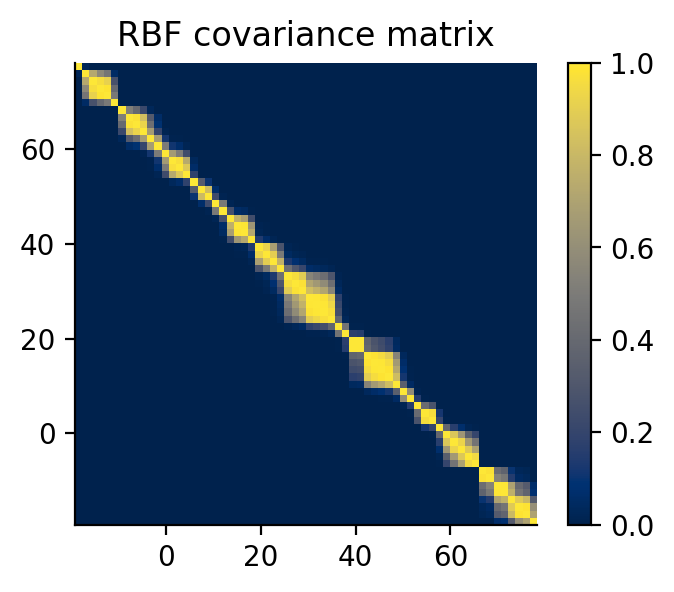

In [8]:
params = {"lengthscale": 1.0, "variance": 1.0}

K = rbf_kernel(params, X, X)

fig, ax = plt.subplots(figsize=[4, 3])
image = ax.imshow(K, extent=[X.min(), X.max(), X.min(), X.max()], cmap="cividis")
fig.colorbar(image)
ax.set_title("RBF covariance matrix")
plt.show()

**If your implementation is correct, what should the diagonal entries be equal to?**

The diagonal entries should equal `variance` (here 1.0), since k(x, x) = α·exp(0) = α.
The plot confirms this: all diagonal entries are 1.0 (yellow).

**What happens to the off-diagonal values when points are far apart?**

The off-diagonal values decay toward 0 as points move further apart.
This is visible in the plot: with lengthscale=1.0, only points that are very
close to each other (near the diagonal) retain high covariance, while all
other entries are essentially 0 (dark blue). This reflects the RBF formula:
as ||x - x'||² grows, the exponential term → 0.

**If you increase the lengthscale, should the covariance matrix become more
local or more global?**

More global. A larger lengthscale λ makes the exponential decay slower,
so points that are farther apart still maintain significant covariance.
The bright region around the diagonal would become wider, meaning the
model assumes correlations over longer distances.


To sample from the GP prior over function values at test inputs `Xt`, we use:

$$
\boldsymbol f_t \sim \mathcal{N}(\boldsymbol 0, \kappa(\boldsymbol X_t, \boldsymbol X_t)).
$$

**Exercise:**
Complete the function below to sample functions from the GP prior.

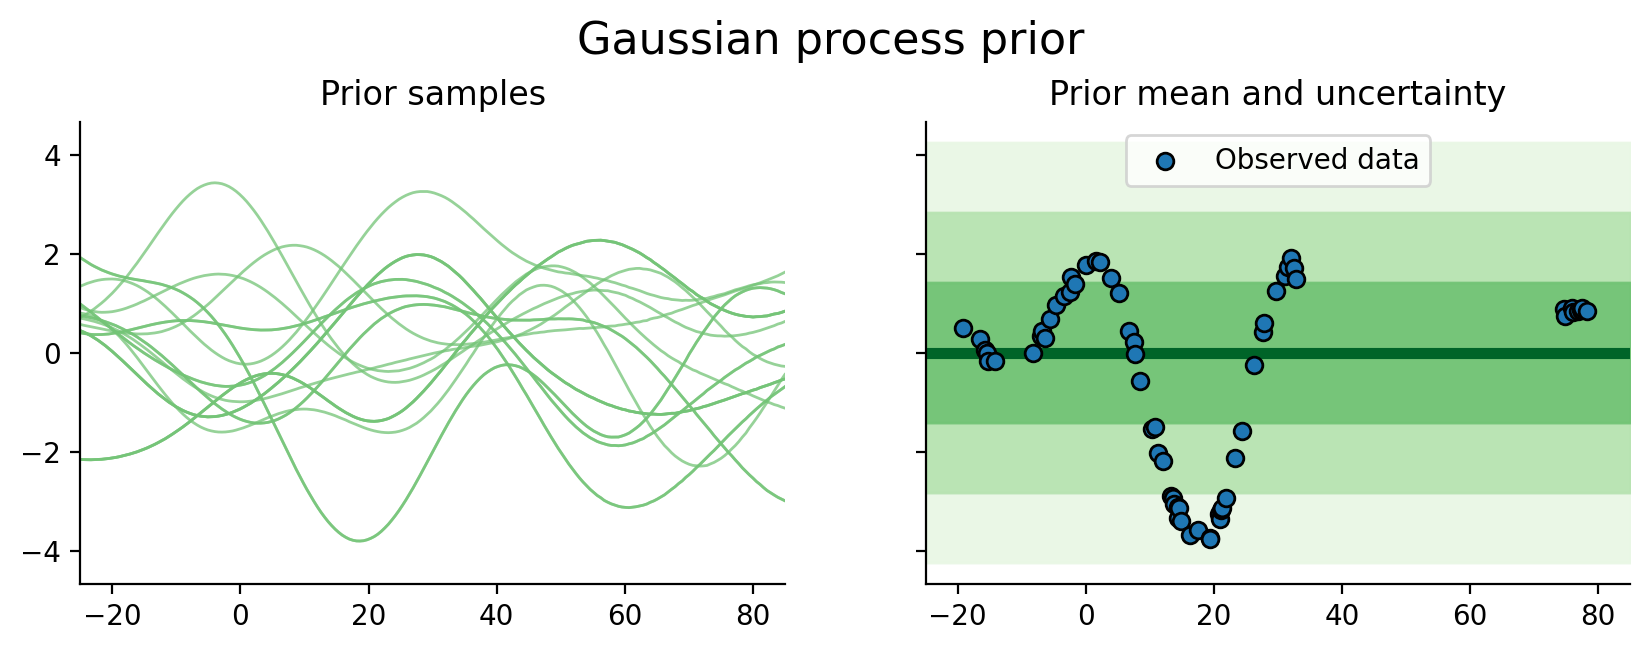

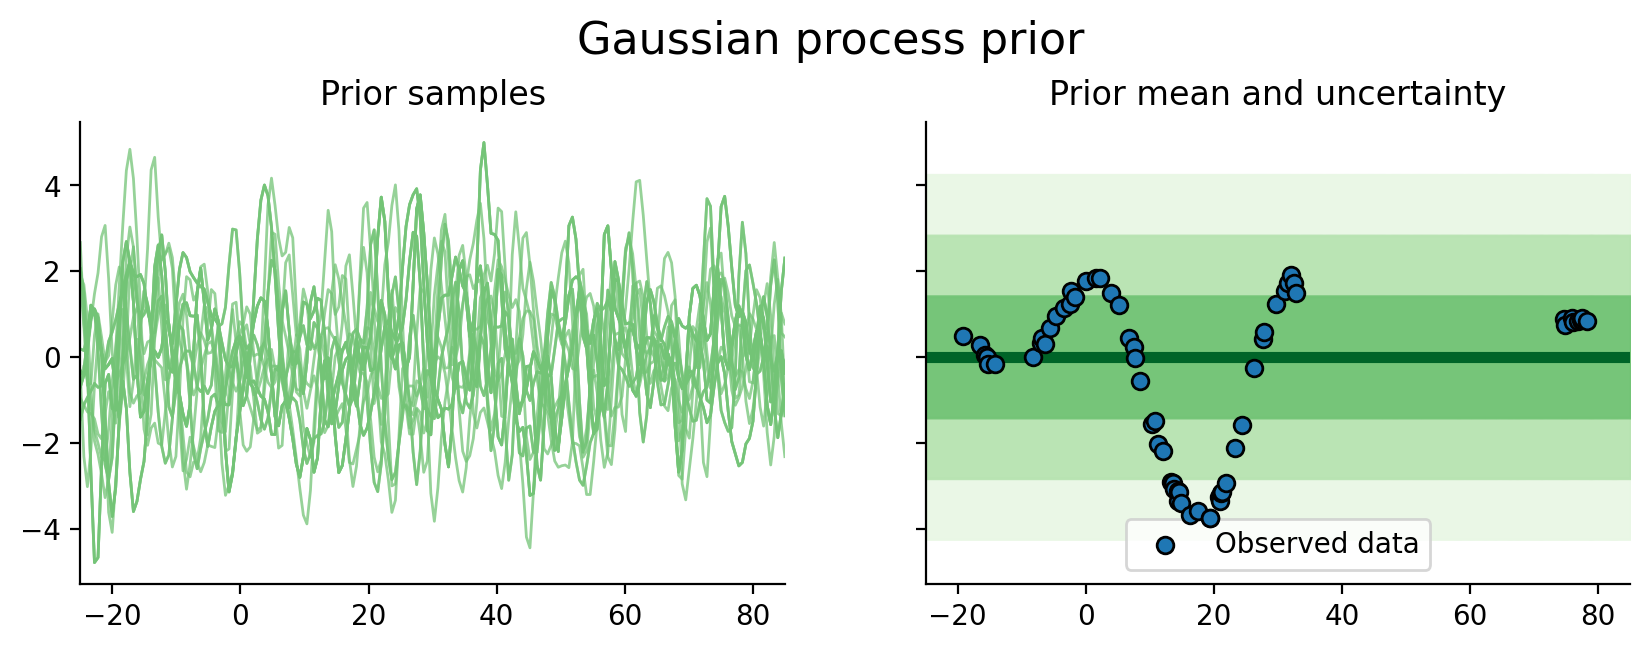

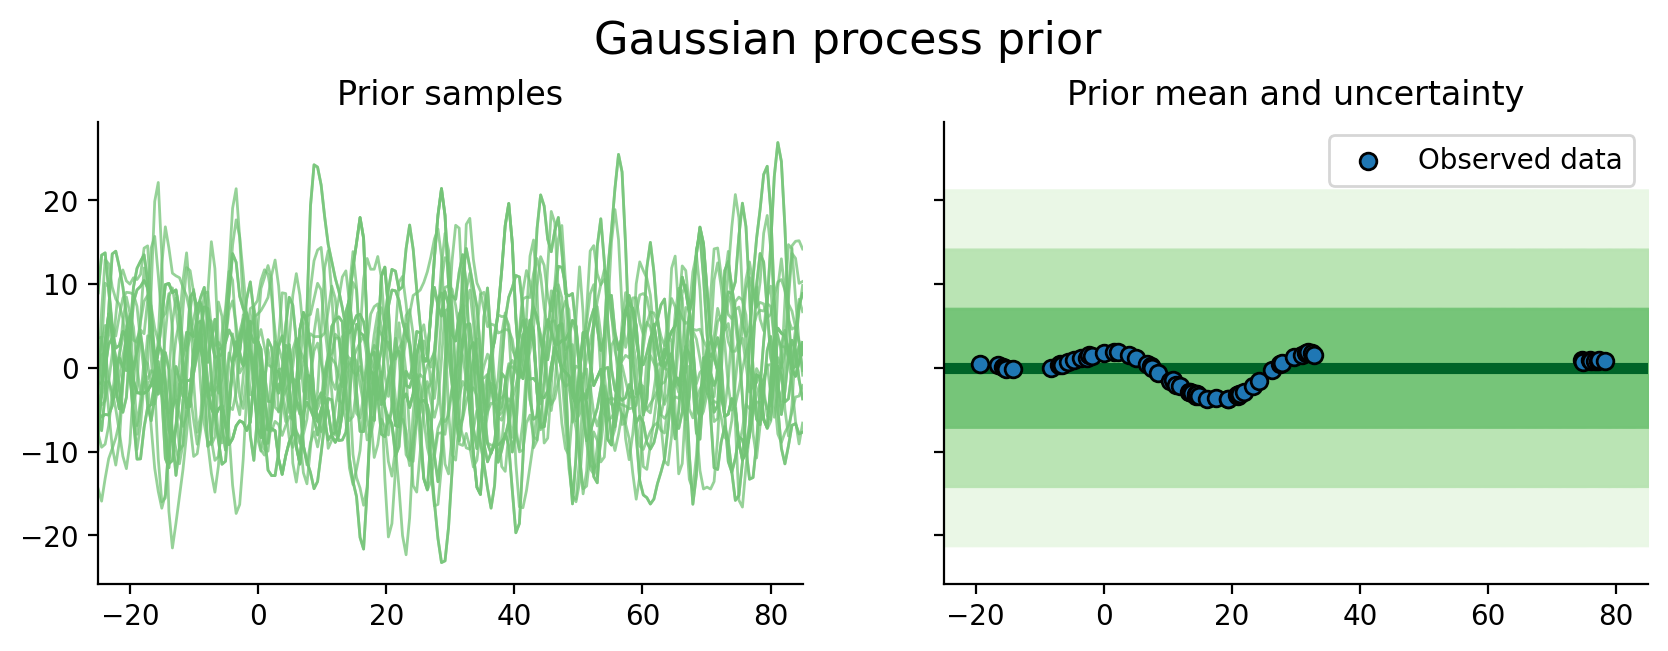

In [13]:
def sample_f_prior(params, kernel_fn, Xt, N=20):
    """Sample N functions from a zero-mean GP prior evaluated at Xt."""
    mean = jnp.zeros(Xt.shape[0])
    cov = kernel_fn(params, Xt, Xt)
    samples = np.random.multivariate_normal(mean, cov, size=N)
    return samples, mean, cov


params = {"lengthscale": 15.0, "variance": 2.0}
samples, mean, cov = sample_f_prior(params, rbf_kernel, Xt)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, ax=ax0)
plot_gp(Xt, mean, cov, ax=ax1)
plot_data(X, y, ax1)
ax0.set_title("Prior samples")
ax1.set_title("Prior mean and uncertainty")
ax1.legend()
fig.suptitle("Gaussian process prior", y=1.05, fontsize=16)
plt.show()


params = {"lengthscale": 1.0, "variance": 2.0}
samples, mean, cov = sample_f_prior(params, rbf_kernel, Xt)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, ax=ax0)
plot_gp(Xt, mean, cov, ax=ax1)
plot_data(X, y, ax1)
ax0.set_title("Prior samples")
ax1.set_title("Prior mean and uncertainty")
ax1.legend()
fig.suptitle("Gaussian process prior", y=1.05, fontsize=16)
plt.show()

params = {"lengthscale": 1.0, "variance": 50.0}
samples, mean, cov = sample_f_prior(params, rbf_kernel, Xt)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, ax=ax0)
plot_gp(Xt, mean, cov, ax=ax1)
plot_data(X, y, ax1)
ax0.set_title("Prior samples")
ax1.set_title("Prior mean and uncertainty")
ax1.legend()
fig.suptitle("Gaussian process prior", y=1.05, fontsize=16)
plt.show()

**Are the prior samples smooth or jagged?**

The prior samples are smooth. This is expected: with lengthscale=15.0, nearby
points are highly correlated, so the sampled functions vary slowly and
continuously across the input space.

**What happens when you decrease the lengthscale?**

As visible in the plot (lengthscale=1.0 vs lengthscale=15.0), decreasing the
lengthscale produces much more jagged and rapidly oscillating functions.
With λ=1.0 points that are only a short distance apart are already nearly
uncorrelated, so the sampled functions change direction very frequently.
With λ=15.0 the samples are smooth and vary slowly across the entire input
space. This confirms that the lengthscale directly controls the
characteristic length over which the function is allowed to vary.

**What happens to the vertical spread when you increase the variance?**
As visible in the plot (variance=50.0 vs variance=2.0), increasing the variance
dramatically expands the vertical spread of both the sampled functions and the
uncertainty bands. The y-axis now ranges from -20 to +20 instead of -4 to +4.
This is consistent with the RBF kernel formula: variance α acts as a global
scaling factor on the covariance matrix, so the prior uncertainty grows
proportionally to α in all regions of the input space, regardless of the
lengthscale.


**Exercise:**
Try at least three different hyperparameter settings and compare the prior samples.
A useful set to try is:
- `(lengthscale=3.0, variance=1.0)`
- `(lengthscale=15.0, variance=1.0)`
- `(lengthscale=15.0, variance=4.0)`


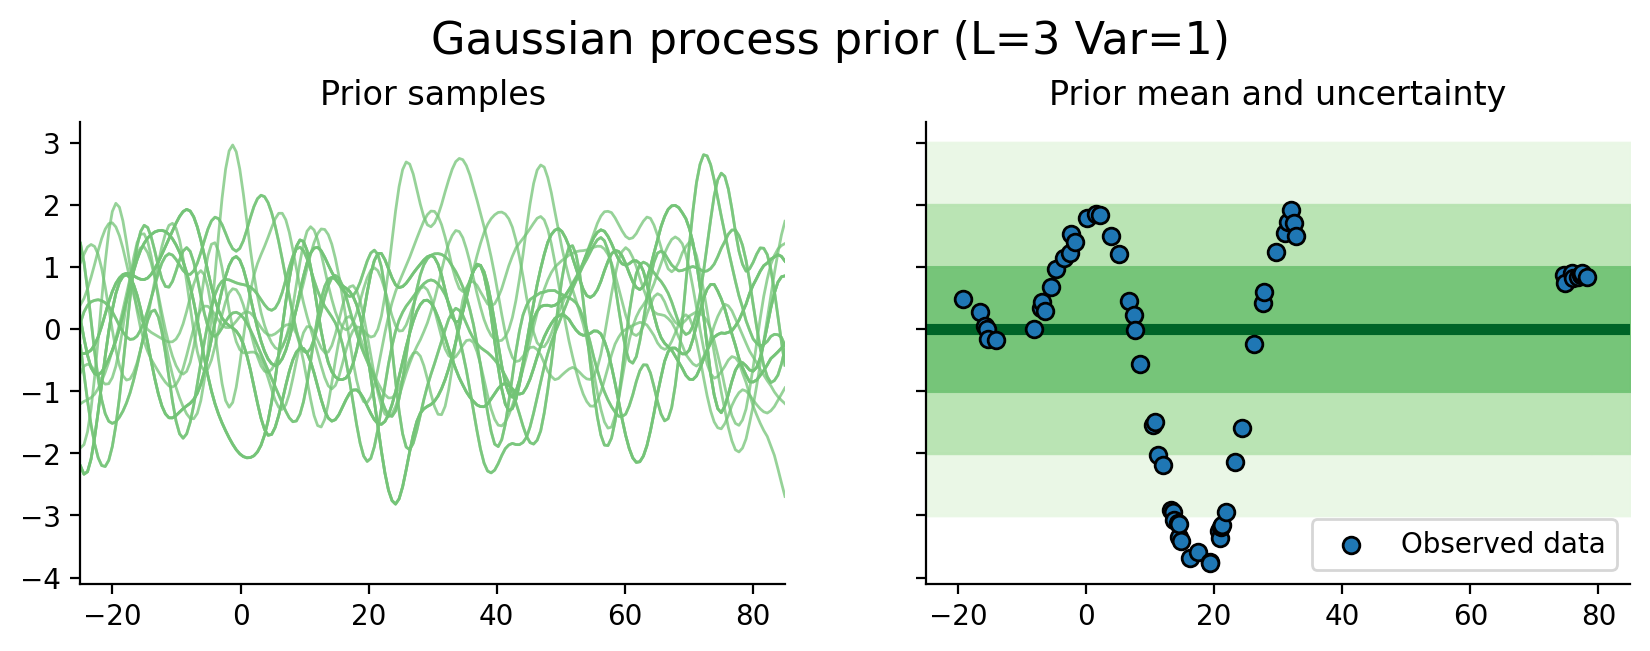

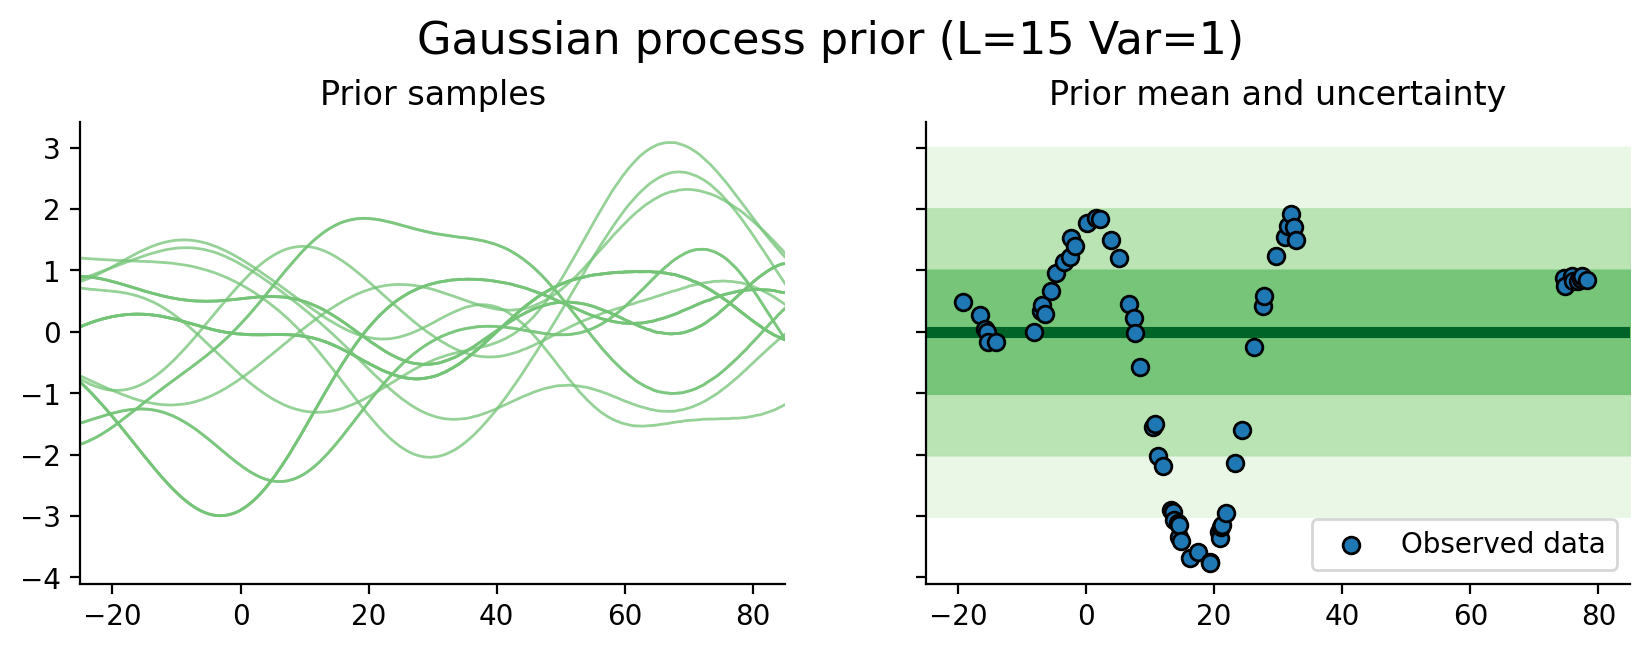

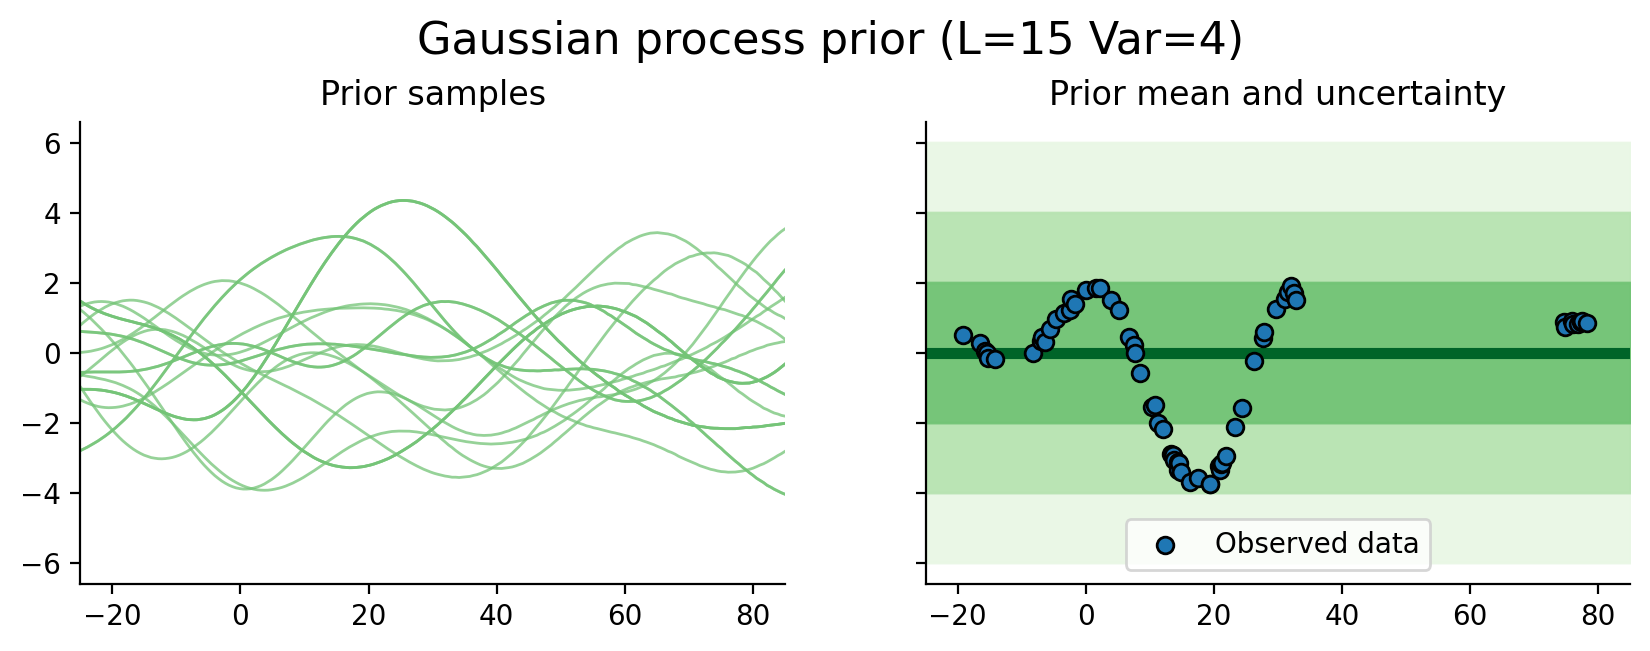

In [16]:
params = {"lengthscale": 3.0, "variance": 1.0}
samples, mean, cov = sample_f_prior(params, rbf_kernel, Xt)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, ax=ax0)
plot_gp(Xt, mean, cov, ax=ax1)
plot_data(X, y, ax1)
ax0.set_title("Prior samples")
ax1.set_title("Prior mean and uncertainty")
ax1.legend()
fig.suptitle("Gaussian process prior (L=3 Var=1)", y=1.05, fontsize=16)
plt.show()

params = {"lengthscale": 15.0, "variance": 1.0}
samples, mean, cov = sample_f_prior(params, rbf_kernel, Xt)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, ax=ax0)
plot_gp(Xt, mean, cov, ax=ax1)
plot_data(X, y, ax1)
ax0.set_title("Prior samples")
ax1.set_title("Prior mean and uncertainty")
ax1.legend()
fig.suptitle("Gaussian process prior (L=15 Var=1)", y=1.05, fontsize=16)
plt.show()

params = {"lengthscale": 15.0, "variance": 4.0}
samples, mean, cov = sample_f_prior(params, rbf_kernel, Xt)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, ax=ax0)
plot_gp(Xt, mean, cov, ax=ax1)
plot_data(X, y, ax1)
ax0.set_title("Prior samples")
ax1.set_title("Prior mean and uncertainty")
ax1.legend()
fig.suptitle("Gaussian process prior (L=15 Var=4)", y=1.05, fontsize=16)
plt.show()

**Comparison of three hyperparameter settings:**


| Setting          | Smoothness        | Vertical spread |
|------------------|-------------------|-----------------|
| L=3,  Var=1      | Jagged, rapidly oscillating | Moderate (±3)  |
| L=15, Var=1      | Smooth, slow variation      | Moderate (±3)  |
| L=15, Var=4      | Smooth, slow variation      | Large (±6)     |


**Lengthscale effect (L=3 vs L=15, same variance):**

Increasing the lengthscale from 3 to 15 produces visibly smoother functions.
With L=3, samples oscillate rapidly and change direction frequently. With L=15,
samples vary slowly and coherently across the entire input space.

**Variance effect (L=15, Var=1 vs L=15, Var=4):**

Increasing the variance from 1 to 4 doubles the vertical spread of both the
samples and the uncertainty bands, while leaving the smoothness completely
unchanged. The shape of the functions is the same — only their scale changes.

**Which setting seems most appropriate for this dataset?**

L=15, Var=1 appears the most reasonable prior for this dataset: the data varies
smoothly over the input range and has an amplitude of roughly ±4, which is
within the 3σ band of this prior setting.

# 2. Posterior Inference

Once we observe data, the prior is updated into a posterior distribution over functions.

For Gaussian process regression, the posterior at test inputs `Xt` is again Gaussian. The main computation involves
kernel matrices and solving a linear system. To do this stably, we use a Cholesky decomposition instead of a direct matrix inverse.

**Exercise:**
Complete the function `predict_f_posterior()`.

Use the following notation:
- `K = k(X, X) + \sigma_n^2 I`
- `Kx = k(X, Xt)`
- `Kxx = k(Xt, Xt)`

Then compute the posterior mean and covariance using triangular solves.

In [17]:
def predict_f_posterior(params, kernel_fn, X, y, Xt, sn2=0.01):
    """Compute the GP posterior mean and covariance at test inputs Xt."""
    K   = kernel_fn(params, X, X) + sn2 * jnp.eye(X.shape[0])    # (N, N)
    Kx  = kernel_fn(params, X, Xt)                               # (N, M)
    Kxx = kernel_fn(params, Xt, Xt)                              # (M, M)

    L = jnp.linalg.cholesky(K)                                   # K = L Lᵀ

    # Solve (K + σ²I) a = y  via two triangular solves
    z = jax.scipy.linalg.solve_triangular(L,   y,  lower=True)   # L z = y
    a = jax.scipy.linalg.solve_triangular(L.T, z,  lower=False)  # Lᵀ a = z

    # Posterior mean: kᵀ_* (K + σ²I)⁻¹ y
    fmean = Kx.T @ a                                             # (M,)

    # Solve L v = Kx  for the variance term
    v = jax.scipy.linalg.solve_triangular(L, Kx, lower=True)     # (N, M)

    # Posterior covariance: k_** - kᵀ_* (K + σ²I)⁻¹ k_*
    fcov = Kxx - v.T @ v                                         # (M, M)

    return fmean, fcov

We first condition on only a few observations. This makes it easier to see how the posterior differs from the prior.

**Exercise:**
Select a small training subset by sampling 5 indices at random.

In [18]:
np.random.seed(14)
idx = np.random.permutation(len(X))[:5]

Xtr = X[idx]
ytr = y[idx]

print(f"Training points: {Xtr.flatten()}")
print(f"Training values: {ytr.flatten()}")

Training points: [ -8.18128681  13.25811133  77.25791517  14.56215491 -15.74802938]
Training values: [-0.00465905 -2.90762394  0.86209602 -3.14481477  0.04240032]


**Exercise:**
Compute the posterior mean and covariance at all test inputs `Xt`.

In [19]:
params = {"lengthscale": 15.0, "variance": 2.0}

f_mean, f_cov = predict_f_posterior(params, rbf_kernel, Xtr, ytr, Xt)

print(f"Posterior mean shape: {f_mean.shape}")
print(f"Posterior covariance shape: {f_cov.shape}")

Posterior mean shape: (200,)
Posterior covariance shape: (200, 200)


**Exercise:**
Draw posterior samples and visualize them together with the posterior uncertainty.

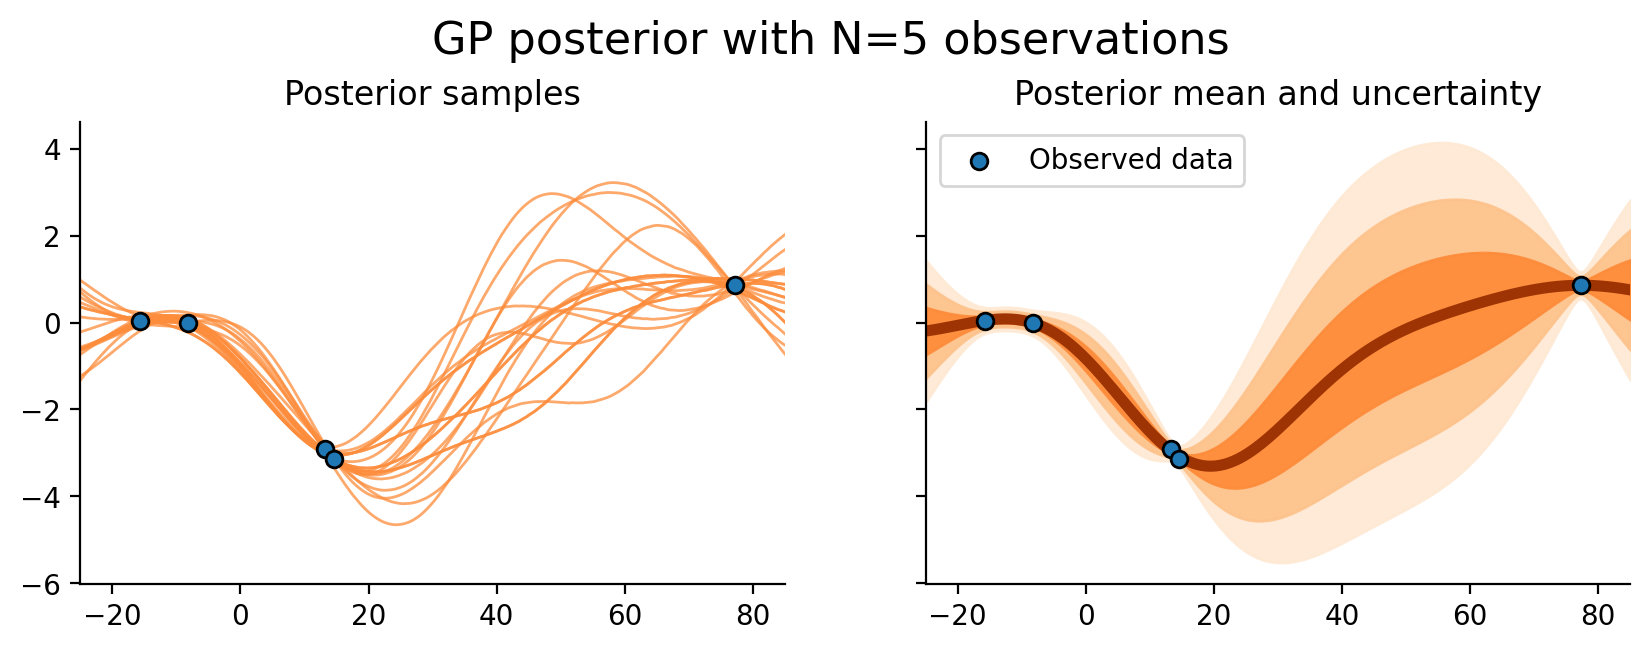

In [20]:
np.random.seed(0)
n_samples = 50

samples = np.random.multivariate_normal(f_mean, f_cov, size=n_samples)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, palette="Oranges", ax=ax0)
plot_data(Xtr, ytr, ax=ax0)
plot_gp(Xt, f_mean, f_cov, ax=ax1, palette="Oranges")
plot_data(Xtr, ytr, ax=ax1)
ax0.set_title("Posterior samples")
ax1.set_title("Posterior mean and uncertainty")
ax1.legend()
fig.suptitle(f"GP posterior with N={len(Xtr)} observations", y=1.05, fontsize=16)
plt.show()

**Does the posterior uncertainty shrink near observed points?**

Yes. The uncertainty bands collapse to near zero at all five observed points,
which is clearly visible in the right panel.

**In the input gap, is the uncertainty larger or smaller than near the observations?**

Much larger. In the region 30 ≲ x ≲ 75, where no observations are present,
the uncertainty bands expand significantly. With only 5 training points the
model has very little information about the function in that region and
reverts toward the prior variance.

**Do the sampled functions interpolate the observed points exactly, or only
approximately? Why?**

The sampled functions pass through the observed points exactly (or nearly so).
With sn2=0.01, the noise variance is very small, so K + σ²I ≈ K and the
posterior is forced to interpolate the data. This is consistent with the
noise model p(y|f) = N(y|f, σ²I) from the lecture notes (p.6): when σ² → 0,
the posterior collapses to exact interpolation at the training points.

**Exercise:**
Now condition on the full dataset and compare the posterior to the previous plot.

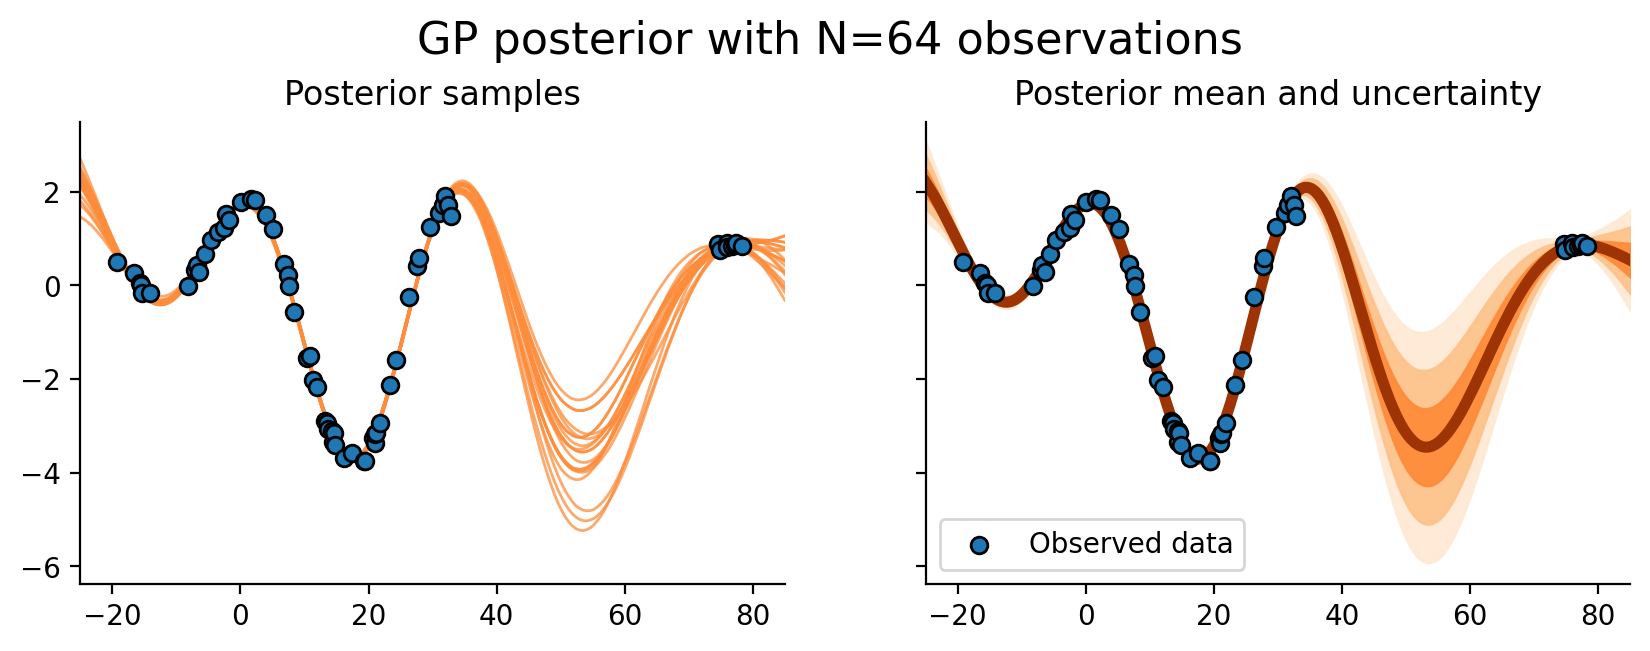

In [22]:
np.random.seed(0)

Xtr, ytr = X, y
f_mean, f_cov = predict_f_posterior(params, rbf_kernel, Xtr, ytr, Xt)
samples = np.random.multivariate_normal(f_mean, f_cov, size=50)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, palette="Oranges", ax=ax0)
plot_data(X, y, ax=ax0)
plot_gp(Xt, f_mean, f_cov, ax=ax1, palette="Oranges")
plot_data(X, y, ax=ax1)
ax0.set_title("Posterior samples")
ax1.set_title("Posterior mean and uncertainty")
ax1.legend()
fig.suptitle(f"GP posterior with N={len(Xtr)} observations", y=1.05, fontsize=16)
plt.show()

**Compared with the 5-point posterior, where did the uncertainty decrease the most?**

The uncertainty decreased the most between x ≈ -10 and x ≈ 40, where the
addition of many new observations collapsed the posterior samples into a
tight line.

**Does the gap still look more uncertain than densely observed regions?**

Yes. In the gap region (40 ≲ x ≲ 70) the uncertainty bands flare out
visibly, while in densely observed regions they are nearly invisible.
This is a core property of GPs: without data, the posterior reverts
toward the prior and the samples begin to diverge again.

**If your code is correct, does the posterior mean follow the global trend of the data?**

Yes. The posterior mean smoothly interpolates the data and provides a
plausible bridge across the gap, continuing the trend from the observed
regions on either side.

**Exercise:**
Try 3 or 4 kernel hyperparameter combinations and compare the posterior each time.

Focus on these questions:
- What kind of posterior mean do you get with a very short lengthscale?
- What kind of posterior mean do you get with a very long lengthscale?
- Which setting seems most plausible for this dataset?

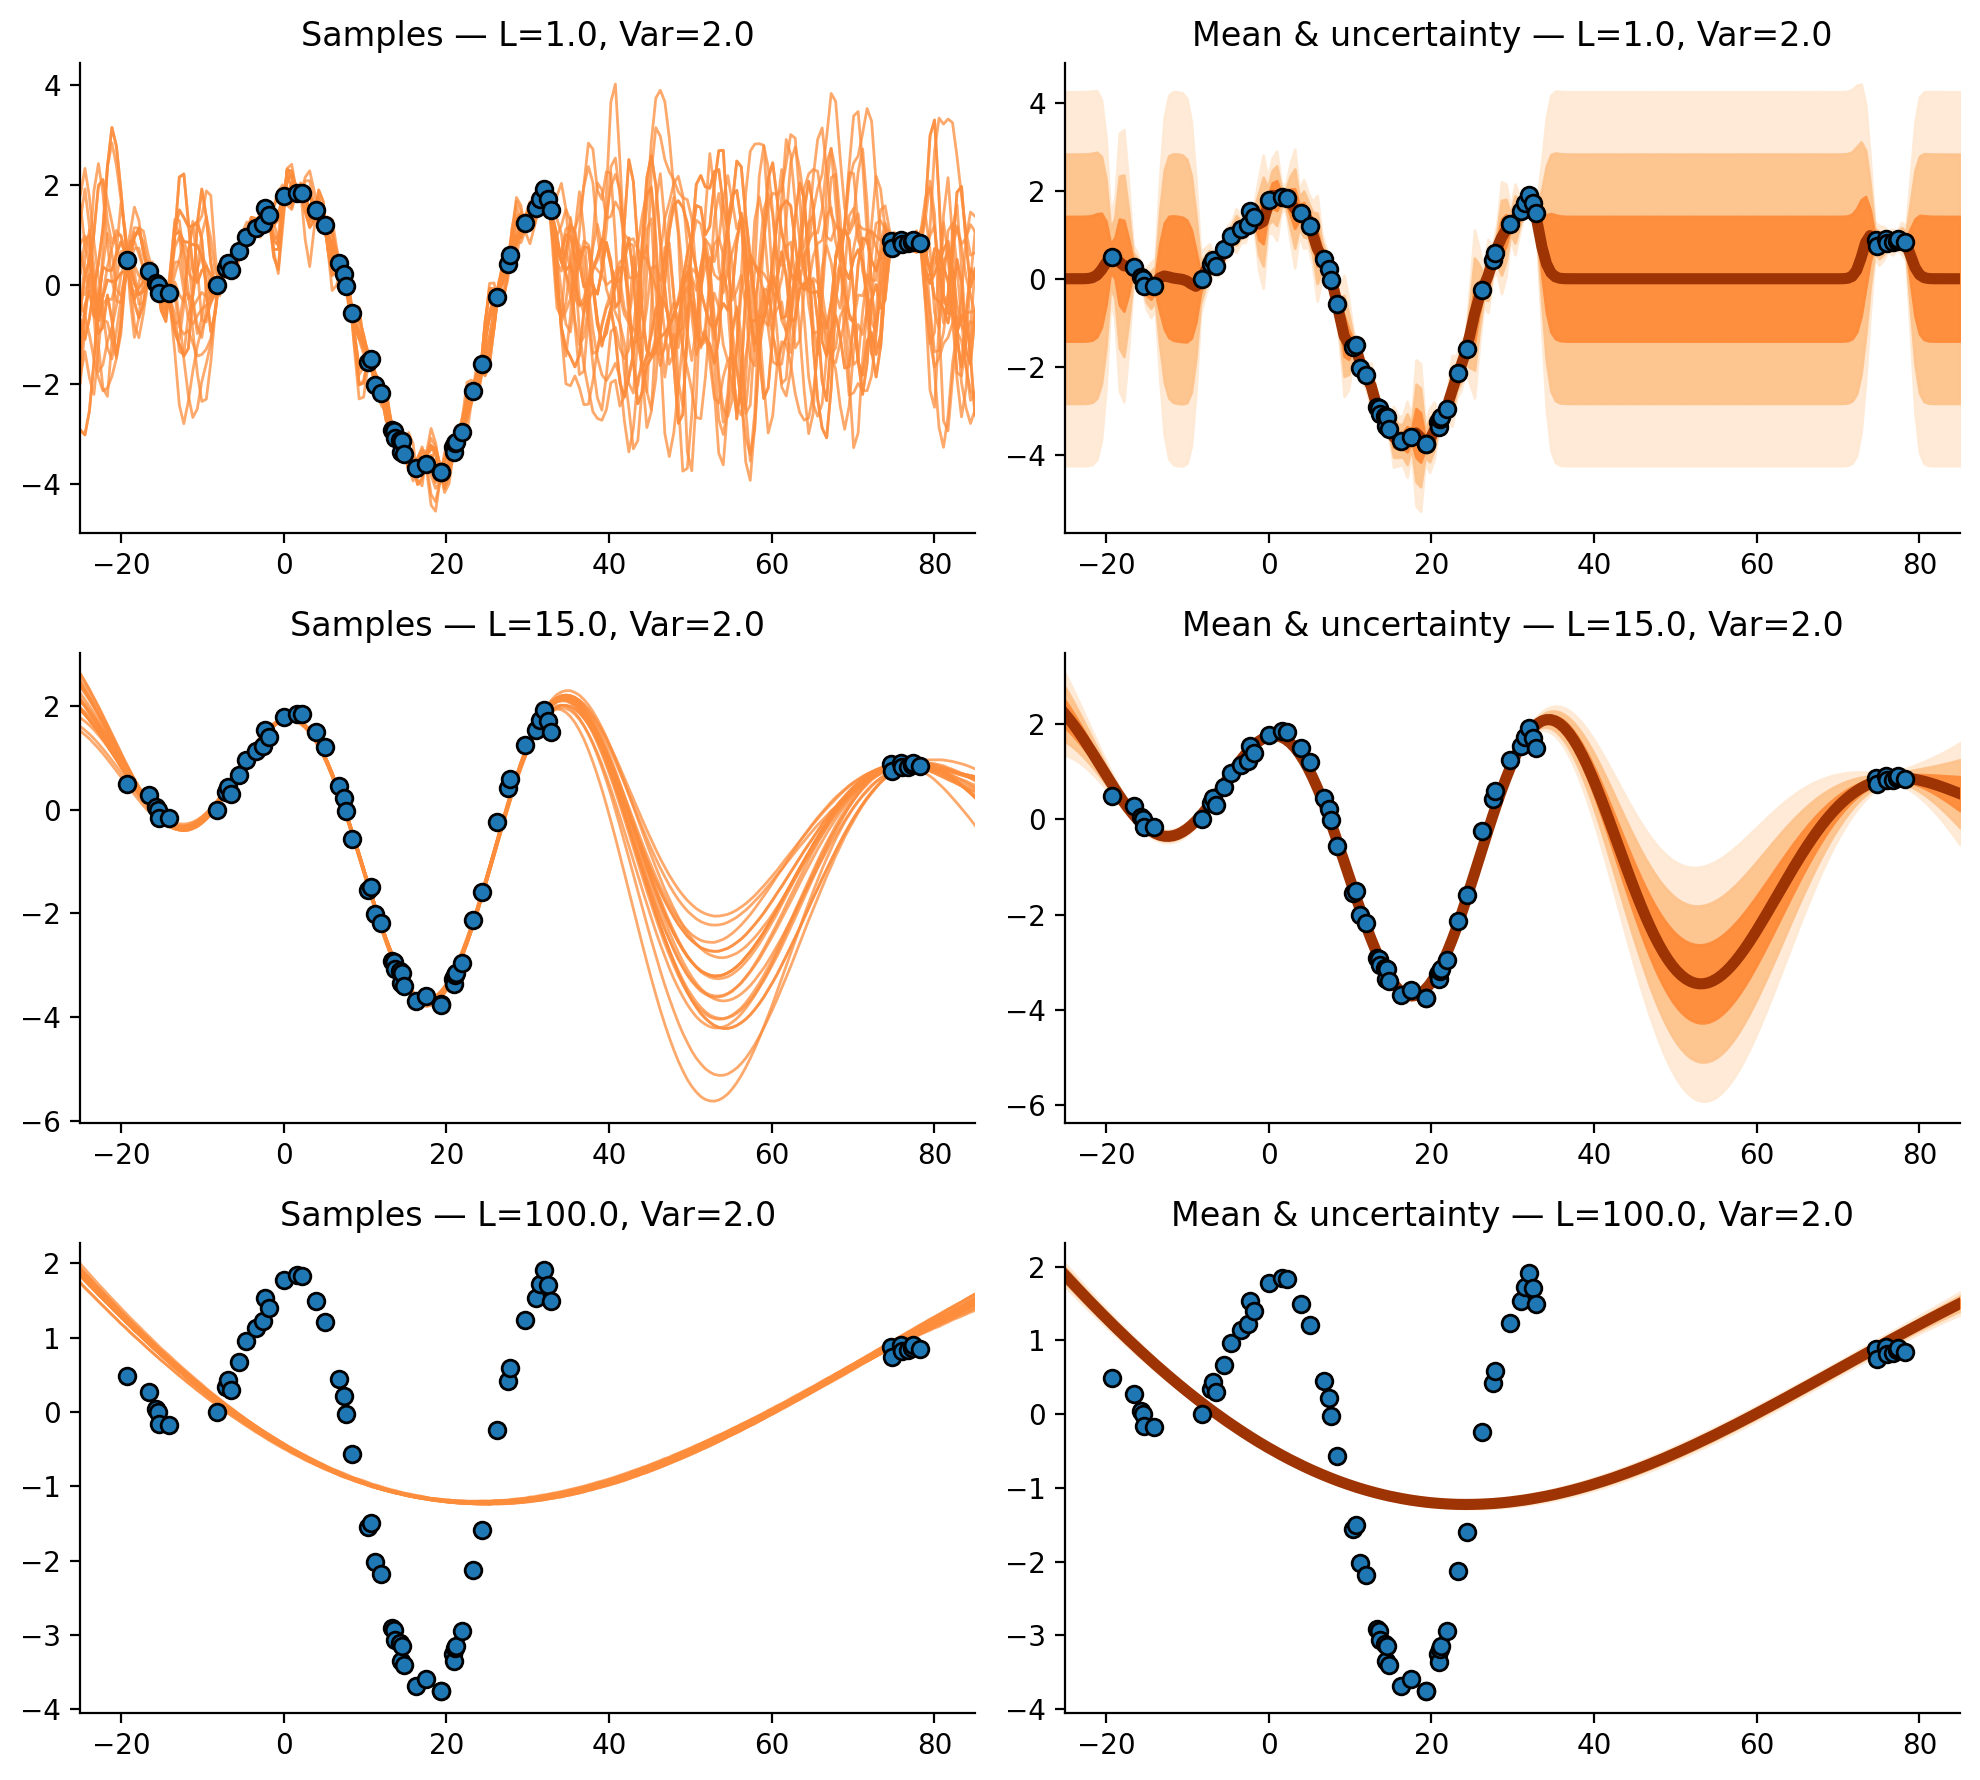

In [23]:
np.random.seed(0)

settings = [
    {"lengthscale": 1.0,   "variance": 2.0},
    {"lengthscale": 15.0,  "variance": 2.0},
    {"lengthscale": 100.0, "variance": 2.0},
]

fig, axes = plt.subplots(len(settings), 2, figsize=[10, 9], sharey=False)

for i, params in enumerate(settings):
    f_mean, f_cov = predict_f_posterior(params, rbf_kernel, X, y, Xt)
    samples = np.random.multivariate_normal(f_mean, f_cov, size=50)

    plot_samples(Xt, samples, palette="Oranges", ax=axes[i, 0])
    plot_data(X, y, ax=axes[i, 0])
    plot_gp(Xt, f_mean, f_cov, ax=axes[i, 1], palette="Oranges")
    plot_data(X, y, ax=axes[i, 1])

    axes[i, 0].set_title(f"Samples — L={params['lengthscale']}, Var={params['variance']}")
    axes[i, 1].set_title(f"Mean & uncertainty — L={params['lengthscale']}, Var={params['variance']}")

plt.tight_layout()
plt.show()

**What kind of posterior mean do you get with a very short lengthscale? (L=1.0)**

With L=1.0, the posterior mean interpolates the data locally but fails to
generalize beyond the observed points. In the gap (40 ≲ x ≲ 70), the model
immediately reverts to zero (the prior mean) and the uncertainty expands to
the full prior variance. The sampled functions are jagged and oscillate
wildly in unobserved regions.

**What kind of posterior mean do you get with a very long lengthscale? (L=100.0)**

With L=100.0, the posterior mean is overly smooth — essentially a single
wide parabola that fails to capture the local oscillations visible in the
data. Points that are far apart are treated as nearly identical, so the
model cannot represent the rapid variations between x ≈ -10 and x ≈ 35.

**Which setting seems most plausible for this dataset? (L=15.0)**

L=15.0 is the most plausible setting. The posterior mean captures the
oscillatory structure of the data, propagates information smoothly across
the gap, and the uncertainty bands expand only where data is absent.

# 3. Model Evaluation with the Marginal Likelihood

A Gaussian process does not only make predictions. It also assigns a probability to the observed data under a given choice of hyperparameters.

This is the marginal likelihood:

$$
\log p(\boldsymbol y\mid\boldsymbol X) = \log \mathcal{N}(\boldsymbol y \mid \boldsymbol 0, \kappa(\boldsymbol X, \boldsymbol X) + \sigma_n^2 I).
$$

It provides a principled way to compare hyperparameter settings.

**Exercise:**
Complete the function below to compute the log marginal likelihood using a Cholesky factorization.

In [24]:
@functools.partial(jax.jit, static_argnums=(1,))
def marginal_likelihood(params, kernel_fn, X, y, sn2=0.01):
    """Compute the log marginal likelihood of the GP model."""
    K = kernel_fn(params, X, X) + sn2 * jnp.eye(X.shape[0])
    L = jnp.linalg.cholesky(K)

    # Solve L V = y
    V = jax.scipy.linalg.solve_triangular(L, y, lower=True)

    # Three terms from the lecture notes (p.12)
    model_fit_term = -0.5 * jnp.dot(V, V)
    log_det_term   = -jnp.sum(jnp.log(jnp.diag(L)))
    ll = model_fit_term + log_det_term - 0.5 * X.shape[0] * jnp.log(2 * jnp.pi)

    return ll

**Exercise:**
Evaluate the marginal likelihood for one hyperparameter setting.

In [25]:
params = {"lengthscale": 15.0, "variance": 1.0}
print(marginal_likelihood(params, rbf_kernel, X, y))

-238.01907


**Exercise:**
Run a grid search over `lengthscale` and `variance`, then visualize the marginal likelihood surface.

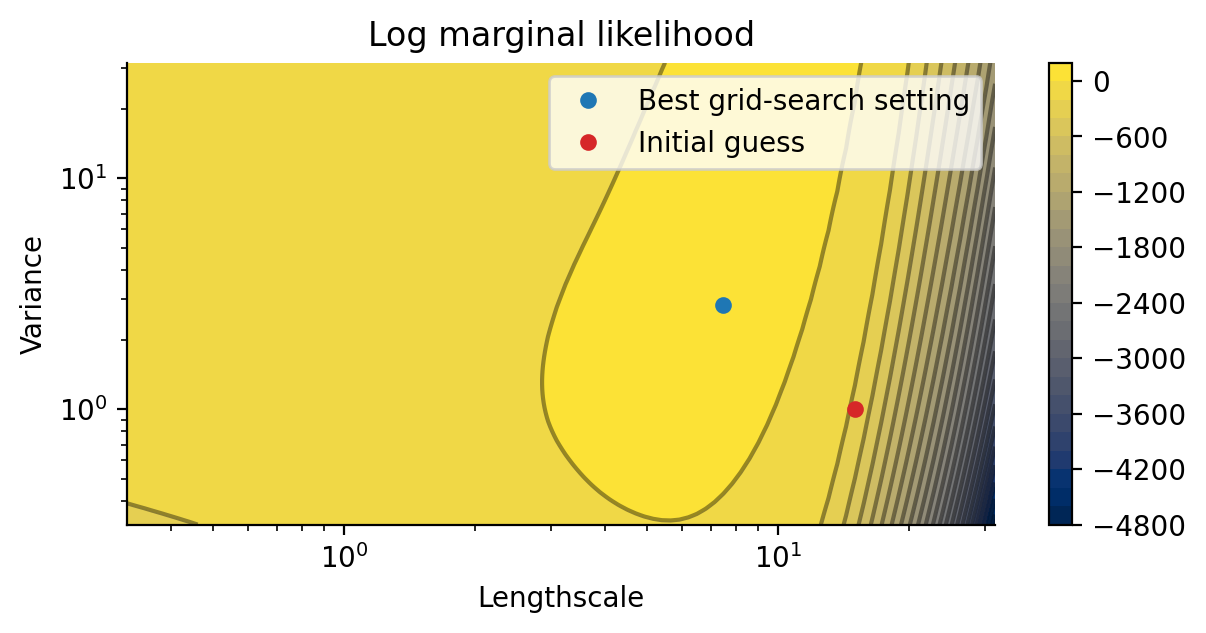

In [26]:
lengthscales = np.logspace(-0.5, 1.5, 100)
variances = np.logspace(-0.5, 1.5, 100)
marginal_ll = np.empty((len(lengthscales), len(variances)))

for i, lengthscale in enumerate(lengthscales):
    for j, variance in enumerate(variances):
        _params = {"lengthscale": lengthscale, "variance": variance}
        marginal_ll[i, j] = marginal_likelihood(_params, rbf_kernel, X, y)

best = np.unravel_index(marginal_ll.argmax(), marginal_ll.shape)

fig, ax = plt.subplots(figsize=(7, 3))
cset = ax.contourf(lengthscales, variances, marginal_ll.T, cmap="cividis", levels=30)
fig.colorbar(cset)
ax.contour(
    lengthscales,
    variances,
    marginal_ll.T,
    colors="k",
    linestyles="-",
    alpha=0.4,
    levels=30,
)
ax.plot(
    lengthscales[best[0]],
    variances[best[1]],
    "o",
    color="tab:blue",
    ms=5,
    label="Best grid-search setting",
)
ax.plot(
    params["lengthscale"],
    params["variance"],
    "o",
    color="tab:red",
    ms=5,
    label="Initial guess",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Lengthscale")
ax.set_ylabel("Variance")
ax.set_title("Log marginal likelihood")
ax.legend()
plt.show()

**Is the best region associated with very short, intermediate, or very long lengthscales?**

The best region is associated with intermediate lengthscales, around L ≈ 7-10
(visible from the blue dot position). Very short lengthscales (L < 3) and
very long lengthscales (L > 20) both yield much lower marginal likelihood
values, consistent with the posterior plots where L=1 was too jagged and
L=100 was too smooth.

**Does the best variance look tiny, huge, or moderate?**

The best variance is moderate, around Var ≈ 2.5-3 (blue dot). The surface
shows that very small variances yield poor fit, while very large variances
are also penalized by the model complexity term in the marginal likelihood
(lecture notes, p.12).

**Do the best hyperparameters match your visual intuition from the posterior plots?**

Yes, broadly. From the posterior comparison we concluded that L=15 was
the most plausible setting visually. The grid search confirms that the
optimal region is in the intermediate lengthscale range, though it
suggests a slightly shorter lengthscale (L ≈ 7-10) than our visual inspection suggested.

# 4. Hyperparameter Optimization with Gradients

Instead of evaluating a large grid, we can optimize the marginal likelihood directly.

You already saw in the JAX tutorial how `jax.grad` and `jax.value_and_grad` work. Here we apply them to GP hyperparameters.

**Exercise:**
Create a function that returns both the marginal likelihood and its gradient with respect to the parameter dictionary.

In [28]:
grad_marginal_likelihood = jax.value_and_grad(marginal_likelihood, argnums=0)
grad_marginal_likelihood = jax.jit(grad_marginal_likelihood, static_argnums=(1,))

We now implement one gradient-ascent update step.

In [29]:
@jax.jit
def gradient_update(params, gradients, learning_rate):
    """Update GP hyperparameters with one gradient-ascent step."""
    updated_params = jax.tree.map(
        lambda p, g: p + learning_rate * g,
        params,
        gradients,
    )
    return updated_params

**Exercise:**
Complete the optimization loop and keep track of the marginal likelihood values.

In [30]:
params = {"lengthscale": 1.0, "variance": 1.0}
learning_rate = 0.001
marginals = []

for _ in range(2000):
    value, gradients = grad_marginal_likelihood(params, rbf_kernel, X, y)
    params = gradient_update(params, gradients, learning_rate)
    marginals.append(value)

params

{'lengthscale': Array(7.0700607, dtype=float32, weak_type=True),
 'variance': Array(2.226173, dtype=float32, weak_type=True)}

**Exercise:**
Plot the marginal likelihood during optimization.

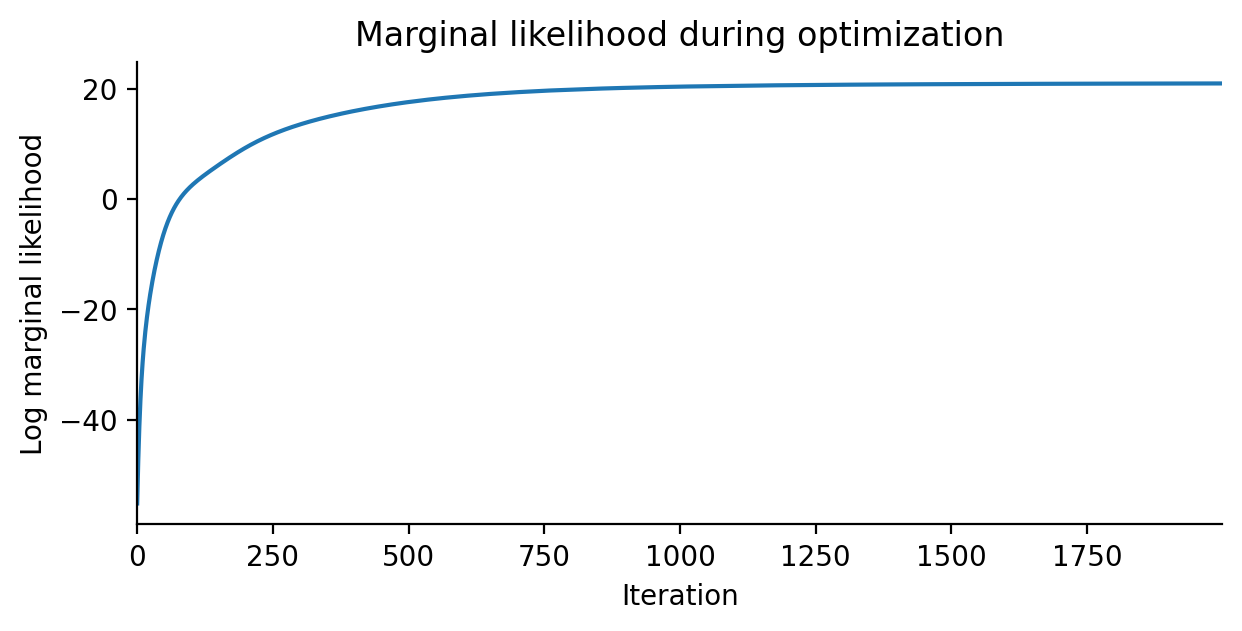

In [31]:
fig, ax = plt.subplots(figsize=[7, 3])
ax.plot(marginals)
ax.set_title("Marginal likelihood during optimization")
ax.set_xlabel("Iteration")
ax.set_ylabel("Log marginal likelihood")
plt.show()

**Does the objective increase over time?**

Yes. The log marginal likelihood increases monotonically from ≈ -60 at
iteration 0 to ≈ +20 at iteration 2000, confirming that gradient ascent
is correctly maximizing the objective.

**Does it improve quickly at the beginning and then plateau?**

Yes. The curve rises steeply in the first ~250 iterations and then
progressively flattens, plateauing around iteration 1000-1250. After
that the improvement is negligible, suggesting that 2000 iterations
is more than sufficient for this problem.

**If the curve is unstable, what might you change first: the learning
rate or the number of iterations?**

The curve here is perfectly stable — no oscillations or divergence.
If it were unstable, the first thing to change would be the learning
rate: a rate that is too large causes the optimizer to overshoot the
optimum and oscillate. Reducing the learning rate would stabilize
the curve, at the cost of needing more iterations to converge.


**Exercise:**
Using the optimized hyperparameters, compute and visualize the posterior again.

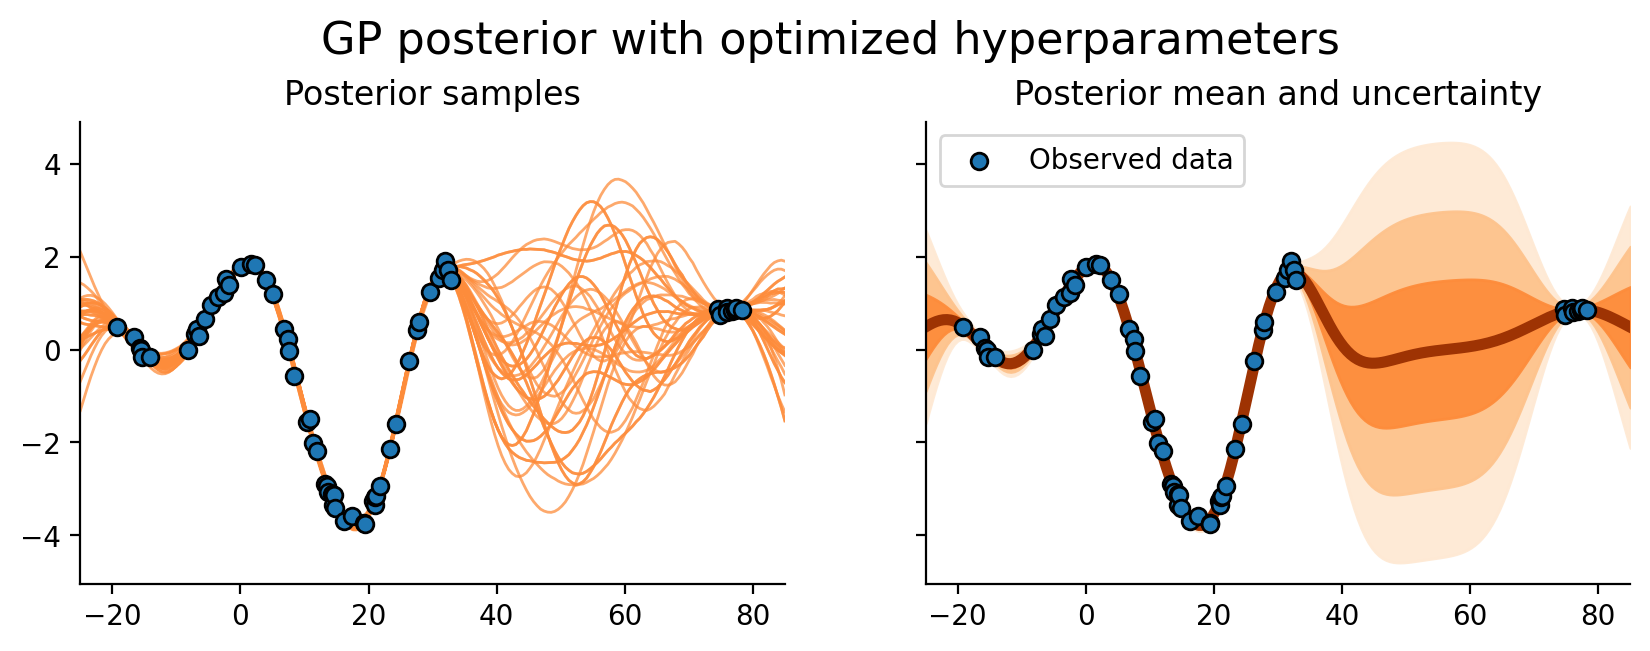

In [32]:
np.random.seed(0)

f_mean, f_cov = predict_f_posterior(params, rbf_kernel, X, y, Xt)
samples = np.random.multivariate_normal(f_mean, f_cov, size=50)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[10, 3], sharey=True)
plot_samples(Xt, samples, palette="Oranges", ax=ax0, N=40)
plot_data(X, y, ax=ax0)
plot_gp(Xt, f_mean, f_cov, ax=ax1, palette="Oranges")
plot_data(X, y, ax=ax1)
ax0.set_title("Posterior samples")
ax1.set_title("Posterior mean and uncertainty")
ax1.legend()
fig.suptitle("GP posterior with optimized hyperparameters", y=1.05, fontsize=16)
plt.show()

**Compared with your earlier posterior plots, does this posterior look more plausible?**

Yes, and more honest. Compared to the N=64 posterior with L=15, the
optimized posterior with L≈7.07 is more plausible for two reasons:
1. It fits the local oscillatory structure of the data better in the
   observed regions.
2. It produces larger uncertainty in the gap (40 ≲ x ≲ 70), which is
   the correct behavior — without observations there, the model should
   be uncertain. With L=15, the long lengthscale was artificially
   propagating confidence into the gap, producing an overconfident
   posterior in a region where no data exists.



**Where is the model still uncertain, and why?**

The model remains uncertain in the gap region (40 ≲ x ≲ 70), where the
uncertainty bands flare out significantly. This is expected: with L≈7.07,
the lengthscale is shorter than with L=15, so the GP propagates information
over a shorter range. Without observations in the gap, the posterior
reverts more quickly toward the prior, producing wider uncertainty bands
than we saw with L=15.

**Are the optimized hyperparameters broadly consistent with the best region
of the grid search?**

Yes. The gradient-based optimization converged to L≈7.07 and Var≈2.23,
which matches the blue dot in the grid search plot (L≈7-8, Var≈2.5).
This confirms that both methods — exhaustive grid search and gradient
ascent — identify the same optimal region of the hyperparameter space.
In practice, gradient-based optimization is preferred: it is computationally cheaper and scales to any number of hyperparameters, making it the standard approach for GP model selection. Grid search is useful mainly for low-dimensional problems where a visual inspection of the likelihood surface is needed.

## Optional extension: Matérn Kernel Vs RBF Kernel


RBF: lengthscale=7.342, variance=2.710, log-ML=21.08
Matern32: lengthscale=15.612, variance=3.964, log-ML=11.05
Matern52: lengthscale=12.561, variance=4.255, log-ML=16.31


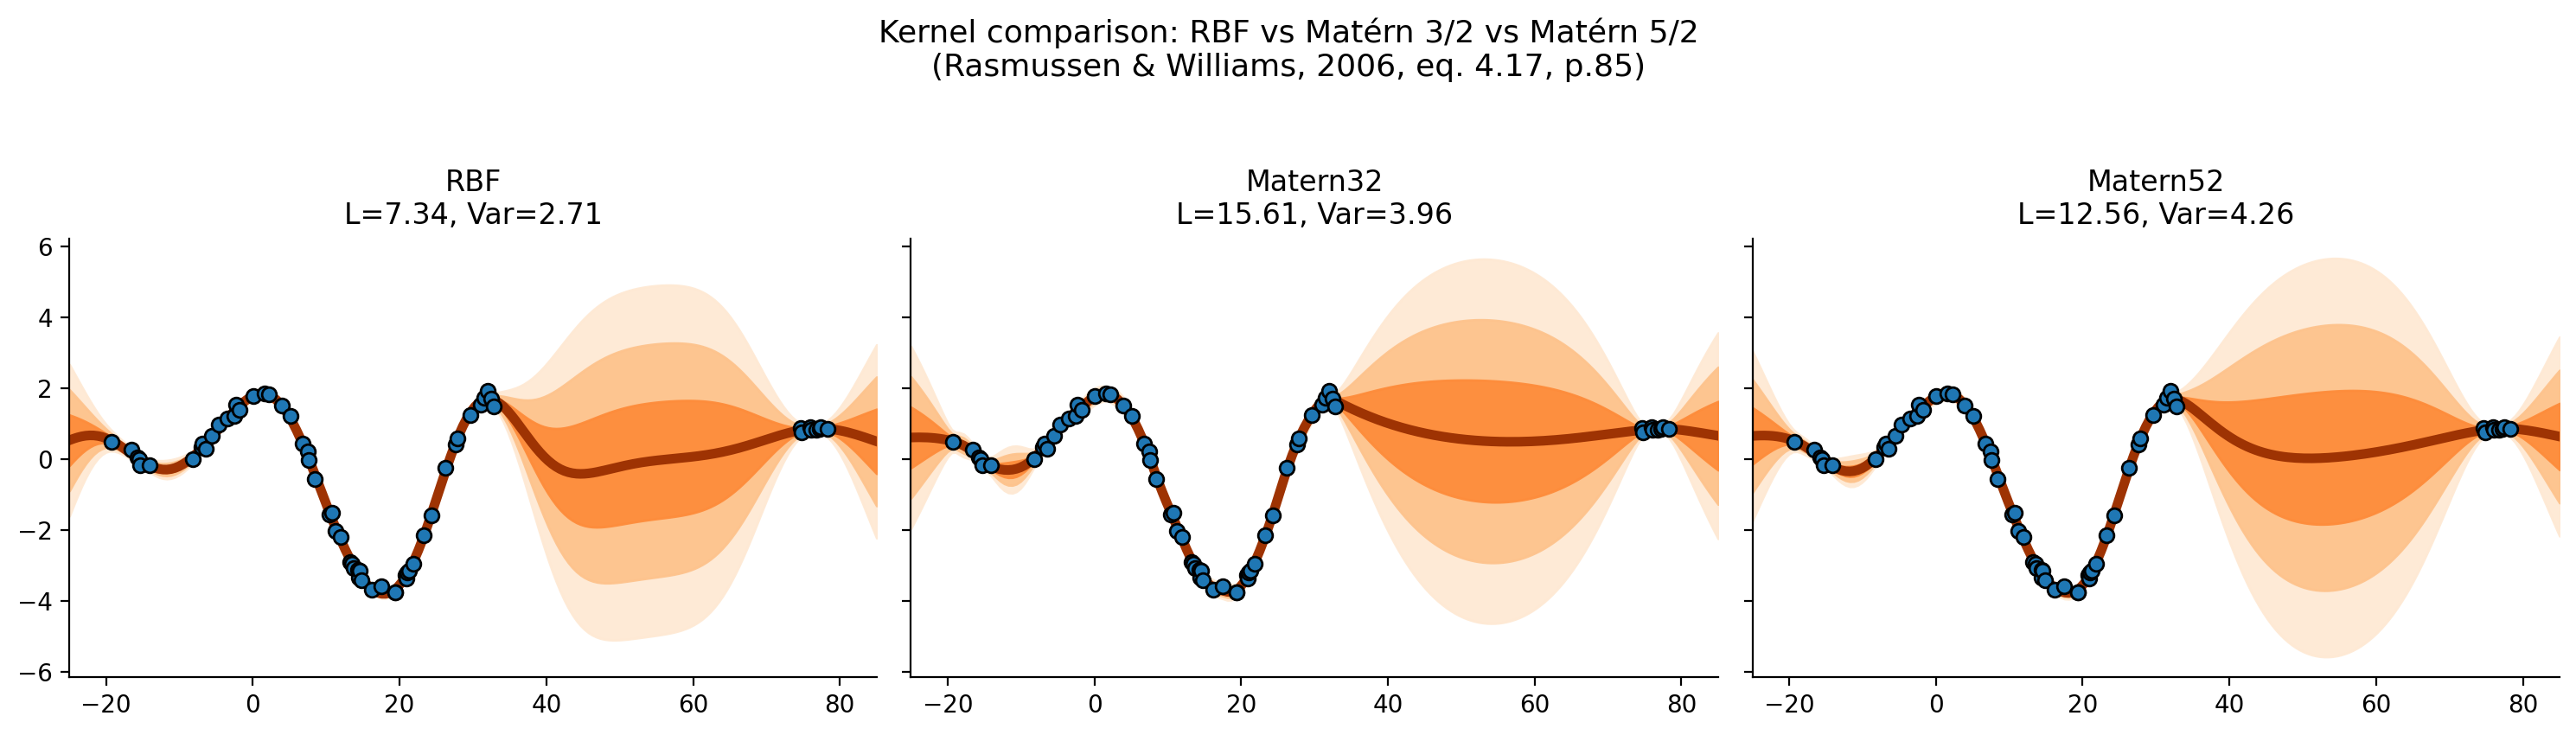

In [42]:
def matern32_kernel(params, X1, X2):
    """Matern nu=3/2 kernel (RW2006 eq. 4.17).
    k(r) = alpha * (1 + sqrt(3)*r/l) * exp(-sqrt(3)*r/l)
    """
    lengthscale = params["lengthscale"]
    variance    = params["variance"]
    # clip before sqrt to avoid NaN from float32 numerical errors
    r = jnp.sqrt(jnp.clip(cdist(X1, X2), a_min=0.0))
    s = jnp.sqrt(3.0) * r / lengthscale
    return variance * (1.0 + s) * jnp.exp(-s)


def matern52_kernel(params, X1, X2):
    """Matern nu=5/2 kernel (RW2006 eq. 4.17).
    k(r) = alpha * (1 + sqrt(5)*r/l + 5*r^2/(3*l^2)) * exp(-sqrt(5)*r/l)
    """
    lengthscale = params["lengthscale"]
    variance    = params["variance"]
    r = jnp.sqrt(jnp.clip(cdist(X1, X2), a_min=0.0))
    s = jnp.sqrt(5.0) * r / lengthscale
    return variance * (1.0 + s + s**2 / 3.0) * jnp.exp(-s)

def marginal_likelihood_log(log_params, kernel_fn, X, y, sn2=0.01):
    """Marginal likelihood with log-space reparametrization.
    Guarantees positivity: params = exp(log_params) > 0 always.
    """
    params = {k: jnp.exp(v) for k, v in log_params.items()}
    return marginal_likelihood(params, kernel_fn, X, y, sn2)

# Optimize each kernel in log-space
results = {}

for name, kernel_fn in [("RBF",      rbf_kernel),
                         ("Matern32", matern32_kernel),
                         ("Matern52", matern52_kernel)]:
    log_p = {"lengthscale": jnp.log(1.0), "variance": jnp.log(1.0)}
    grad_ml = jax.jit(
        jax.value_and_grad(marginal_likelihood_log, argnums=0),
        static_argnums=(1,)
    )
    for _ in range(2000):
        value, grads = grad_ml(log_p, kernel_fn, X, y)
        log_p = gradient_update(log_p, grads, 0.001)

    p = {k: float(jnp.exp(v)) for k, v in log_p.items()}
    results[name] = (p, kernel_fn)
    print(f"{name}: lengthscale={p['lengthscale']:.3f}, "
          f"variance={p['variance']:.3f}, log-ML={float(value):.2f}")


# Plot
np.random.seed(0)
fig, axes = plt.subplots(1, 3, figsize=[15, 4], sharey=True)

for ax, (name, (p, kernel_fn)) in zip(axes, results.items()):
    f_mean, f_cov = predict_f_posterior(p, kernel_fn, X, y, Xt)
    plot_gp(Xt, f_mean, f_cov, ax=ax, palette="Oranges")
    plot_data(X, y, ax=ax)
    ax.set_title(f"{name}\nL={p['lengthscale']:.2f}, Var={p['variance']:.2f}")

plt.suptitle("Kernel comparison: RBF vs Matérn 3/2 vs Matérn 5/2\n"
             "(Rasmussen & Williams, 2006, eq. 4.17, p.85)",
             y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

I implemented two additional kernels from Rasmussen & Williams (2006),
eq. (4.17), p.85, and compared them to the RBF kernel.

| Kernel    | Lengthscale | Variance |
|-----------|-------------|----------|
| RBF       | 7.34        | 2.71     |
| Matérn 32 | 15.61       | 3.96     |
| Matérn 52 | 12.56       | 4.26     |

All three kernels fit the observed data well. The main difference lies in
the gap region (40 ≲ x ≲ 70): the Matérn kernels produce wider uncertainty
bands than RBF, which is consistent with their assumption of less smoothness
— Matérn 3/2 assumes once-differentiable functions, Matérn 5/2 assumes
twice-differentiable functions, while RBF assumes infinite differentiability.
In terms of posterior mean, all three kernels produce similar results in the
observed regions, with the Matérn kernels reverting more quickly to the prior
mean in unobserved regions.